In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [3]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

# 1. Handling Missing Values

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].mean()).astype(int)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4   Income               2240 non-null   int64 
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

# Feature Engineering

In [7]:
# Age
df["Age"] = 2026 - df["Year_Birth"] 

# Calculation of customer joinig tenure days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)
reference_date = df["Dt_Customer"].max()
df["customer_tenure_days"] =( reference_date - df["Dt_Customer"]).dt.days

# Spending
df["Total_Spending"] = df["MntWines"]+ df["MntFruits"] + df["MntMeatProducts"]+ df["MntFishProducts"]+ df["MntSweetProducts"]+ df['MntGoldProds']

# Children
df["total_children"] = df['Kidhome']+ df['Teenhome']



In [8]:
# Education (COnvert into 3 simple categiories)
df["Education"].value_counts()
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "PostGraduate", "PhD": "PostGraduate"
})

In [9]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
Undergraduate     257
Name: count, dtype: int64

In [10]:
# Martial status
df["Marital_Status"].value_counts()
df["Leaving_with"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single" : "Alone", "Alone" : "Alone", "YOLO": "Alone" , "Absurd": "Alone", "Widow": "Alone", "Divorced": "Alone"
})

In [11]:
df["Leaving_with"].value_counts()

Leaving_with
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop Unnecessary Columns

In [12]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome","Teenhome", "Dt_Customer"]
spending_cols = ["MntWines",'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

del_cols = cols+ spending_cols
clean_df = df.drop(columns = del_cols)

In [13]:
clean_df.shape

(2240, 15)

In [14]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'Total_Spending',
       'total_children', 'Leaving_with'],
      dtype='object')

In [15]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,total_children,Leaving_with
0,5524,1957,Graduate,Single,58138,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PostGraduate,Married,58293,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduate,Married,61223,0,1,2013-06-13,46,709,...,3,4,5,0,0,59,381,1341,1,Partner
2236,4001,1946,PostGraduate,Together,64014,2,1,2014-06-10,56,406,...,2,5,7,0,0,80,19,444,3,Partner
2237,7270,1981,Graduate,Divorced,56981,0,0,2014-01-25,91,908,...,3,13,6,0,0,45,155,1241,0,Alone
2238,8235,1956,PostGraduate,Together,69245,0,1,2014-01-24,8,428,...,5,10,3,0,0,70,156,843,1,Partner


# HAndle Outliers

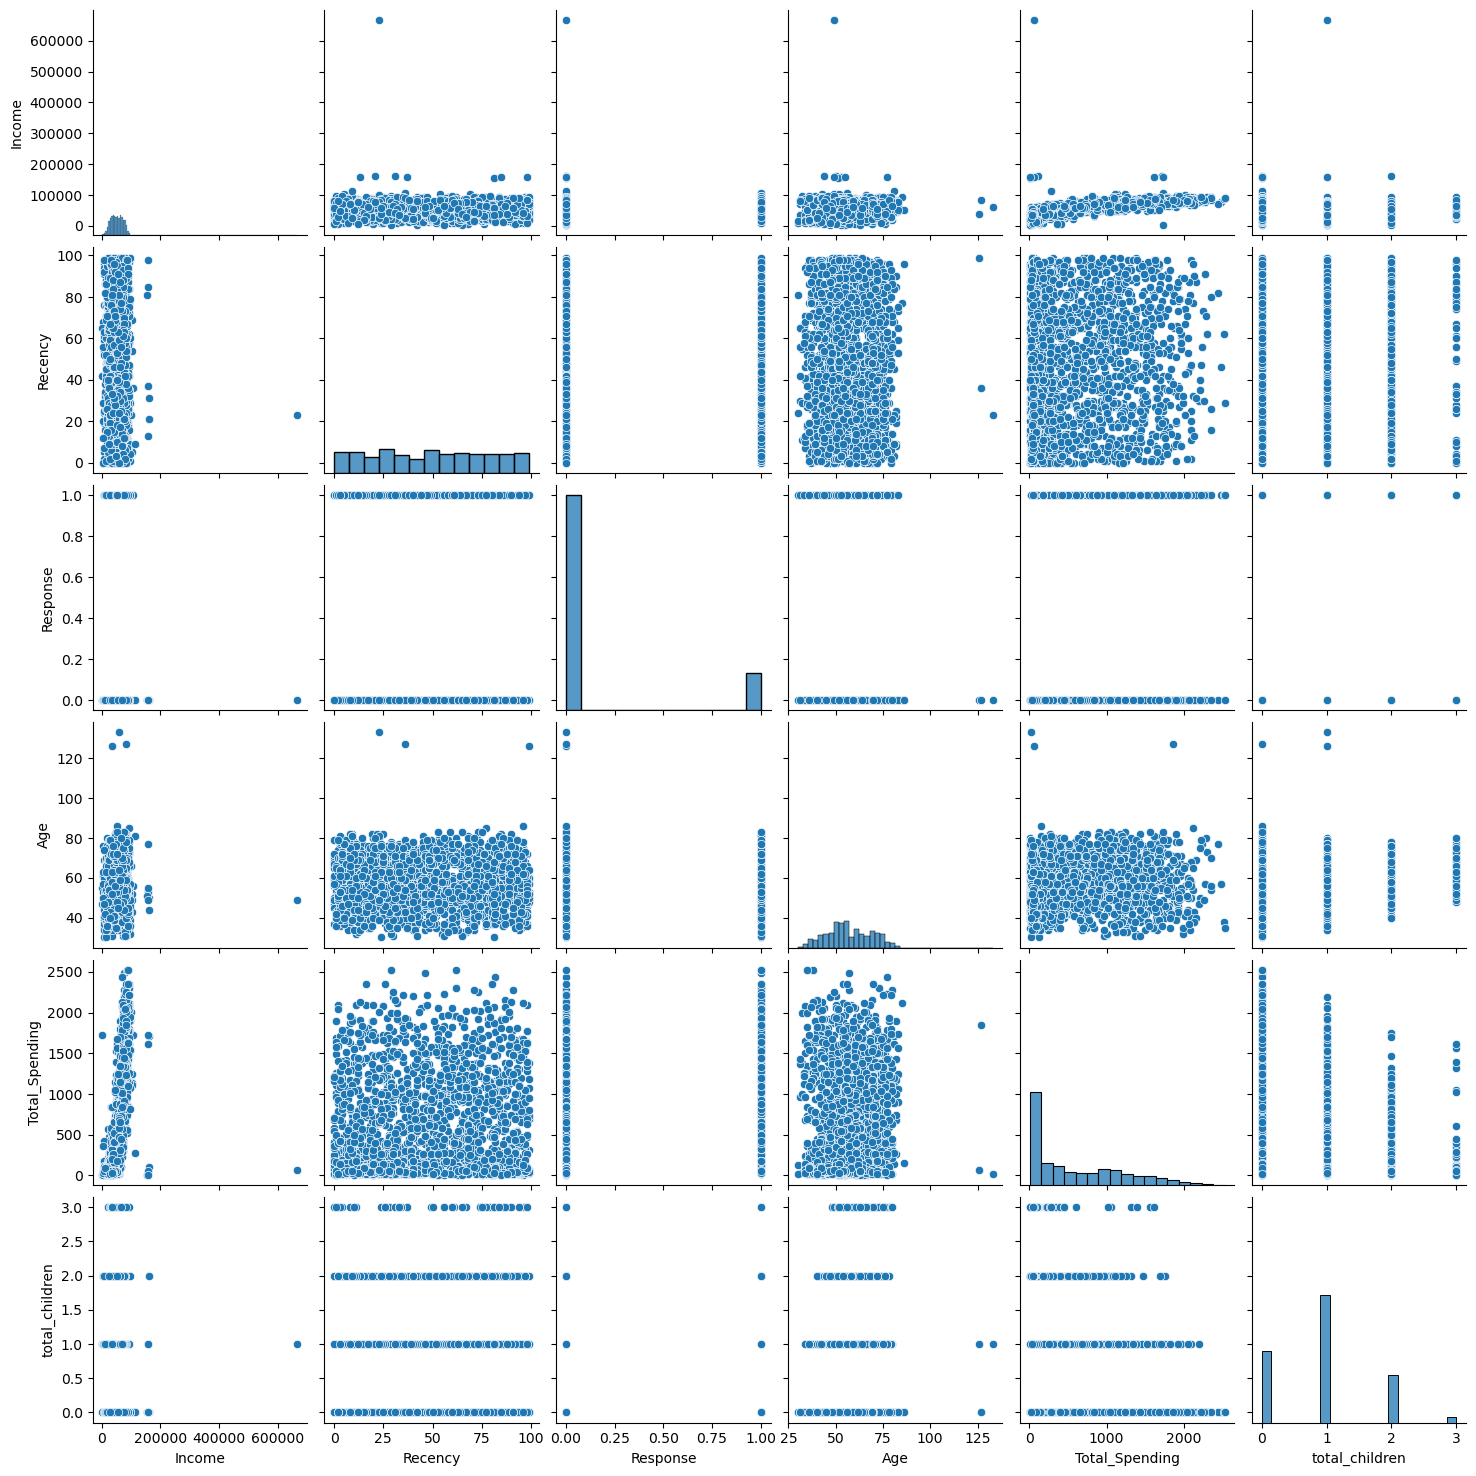

In [16]:
cols = ["Income",  "Recency", "Response", "Age", "Total_Spending", "total_children"]
sns.pairplot(clean_df[cols])

In [17]:
# Remove outlier
print("data size with outliers: ",len(clean_df))

clean_df = clean_df[clean_df["Age"] < 90 ]
clean_df = clean_df[clean_df["Income"] <600000]

print("data size without outliers: ",len(clean_df))

data size with outliers:  2240
data size without outliers:  2236


# Heatmap

In [18]:
corr = clean_df.corr(numeric_only = True)
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,total_children
Income,1.000000,0.007963,-0.107140,0.450579,0.693660,0.627943,-0.646426,-0.027912,0.160990,0.198889,-0.023665,0.789292,-0.340378
Recency,0.007963,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107140,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450579,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693660,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.627943,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646426,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027912,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.160990,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198889,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Axes: >

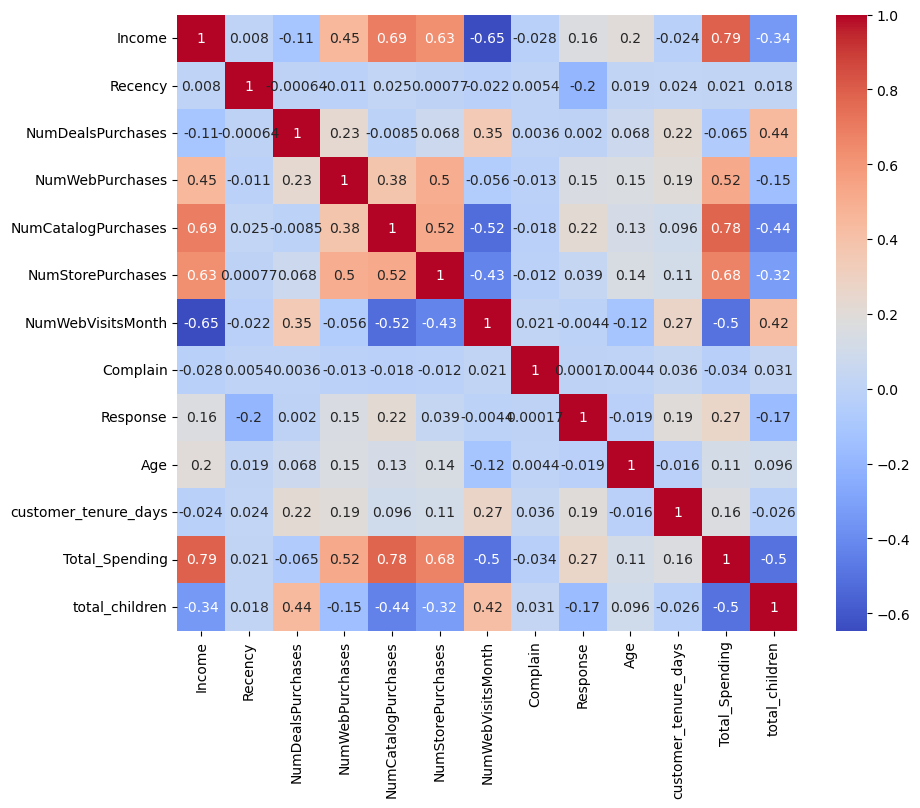

In [19]:
plt.figure(figsize = (10,8))
sns.heatmap(corr, annot = True, cmap ="coolwarm")

In [20]:
# Analysis of heatmap
# increase wrt to another
    # Income vs Total_Spending , NumofCatalogPurchase
    # NumofCatalogPurchase vs Total_Spending , NumStorePurchase

# decrease wrt to another
    # NumberWebvisitmonth  vs Income , NumofCatalogPurchase
    # NumofCatalogPurchase vs total_children
    # total_spending vs total_children

# Handle Missing Values

In [21]:
# One Hot Encoder
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_cols = ["Education", "Leaving_with"]
enc_cols = ohe.fit_transform(clean_df[cat_cols])


In [22]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index = clean_df.index)
enc_df.head()

,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Leaving_with_Alone,Leaving_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [26]:
df_encoded = pd.concat([clean_df.drop(columns = cat_cols), enc_df],axis =1)
df_encoded.shape

(2236, 18)

In [27]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,total_children,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Leaving_with_Alone,Leaving_with_Partner
0,58138,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df_encoded
X_scaled = scaler.fit_transform(X)

In [29]:
X_scaled

array([[ 0.28851342,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.26243773, -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.9179917 , -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.23446471,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.8073717 , -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04237457, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

# PCA

In [36]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D visvialisation')

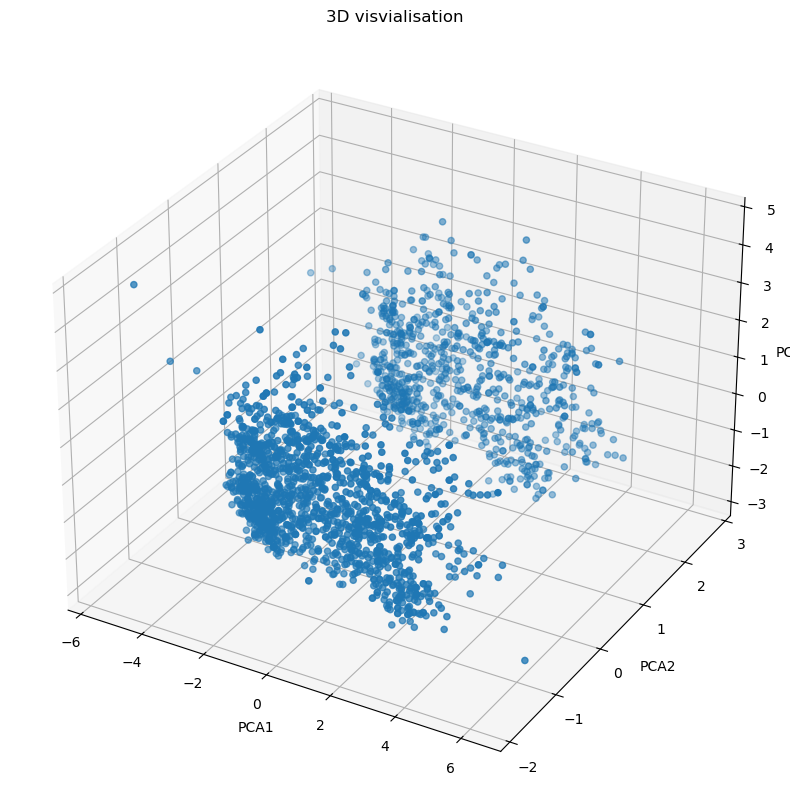

In [40]:
# plt.scatter(x=X_pca[:,0], y= X_pca[:,1] )
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1] , X_pca[:,2] )

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D visvialisation")

# Analysis of K value

In [59]:
# Elbow method
from sklearn.cluster import KMeans
wcss =[]
for k in range (1,11):
    kmeans = KMeans(n_clusters = k, random_state=0)
    kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)

In [60]:
from kneed import  KneeLocator
knee = KneeLocator(range(1,11), wcss, curve = 'convex', direction ='decreasing')
optimal_k = knee.elbow
print("optimal k: ", optimal_k)

optimal k:  4


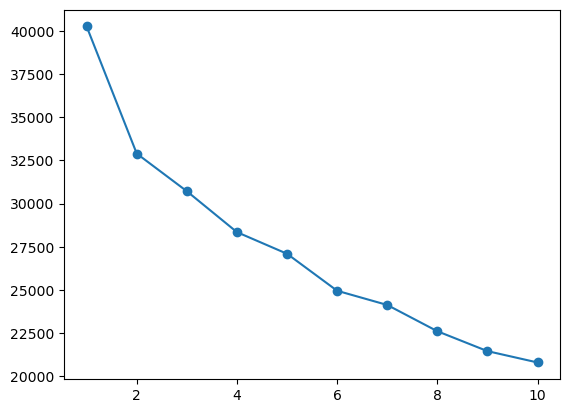

In [61]:
# Elbow method plot
plt.plot(range(1,11), wcss, marker ="o")

In [70]:
# Silhautte Score
from sklearn.metrics import silhouette_score
ss = []
for k in range(2,11):
    kmeans = KMeans(n_clusters= k, random_state =42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    ss.append(score)
    

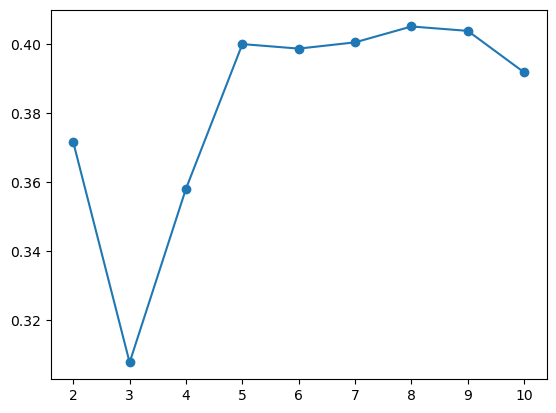

In [71]:
plt.plot(range(2,11), ss, marker ="o")

# K Means Clustering


In [72]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3D visvialisation')

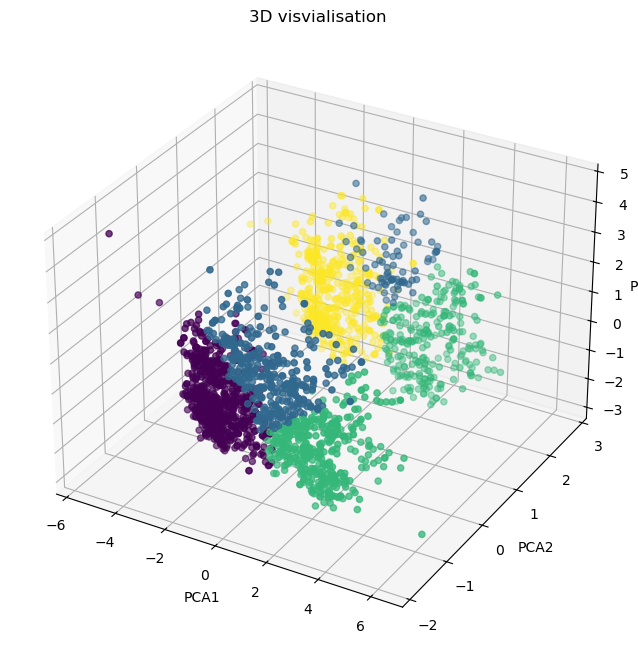

In [75]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1] , X_pca[:,2], c= labels_kmeans )

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D visvialisation")

# Agglomerative Clustering

In [80]:
from sklearn.cluster import AgglomerativeClustering
agglomerative = AgglomerativeClustering(n_clusters = 4)
labels_agglomerative = agglomerative.fit_predict(X_pca)

Text(0.5, 0.92, '3D visvialisation')

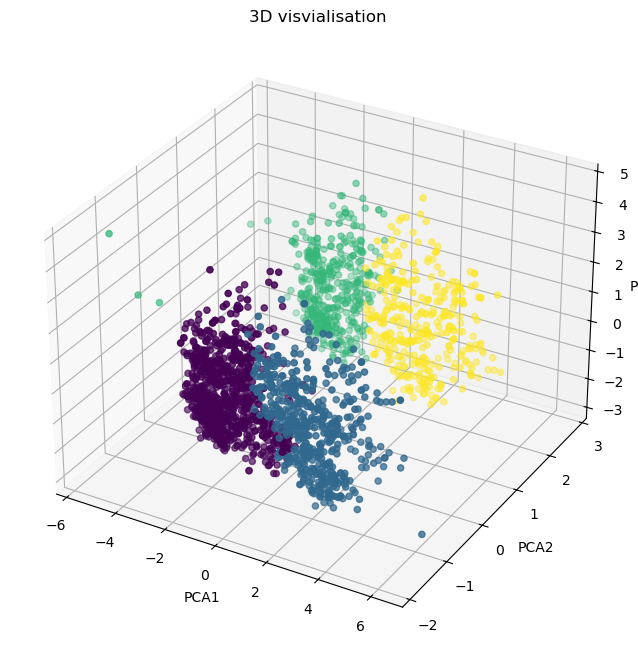

In [81]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1] , X_pca[:,2], c= labels_agglomerative  )

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D visvialisation")

In [96]:

X["clusters"] = labels_agglomerative
X

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,total_children,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Leaving_with_Alone,Leaving_with_Partner,clusters
0,58138,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0,0
2236,64014,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0,0
2237,56981,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0,3
2238,69245,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0,1


<Axes: xlabel='clusters', ylabel='count'>

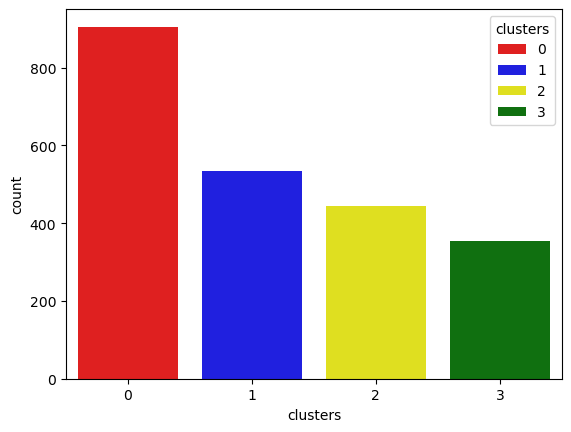

In [97]:
pal = ["red","blue","yellow", "green"]
sns.countplot(x= X["clusters"], palette =pal, hue = X["clusters"] )

<Axes: xlabel='Total_Spending', ylabel='Income'>

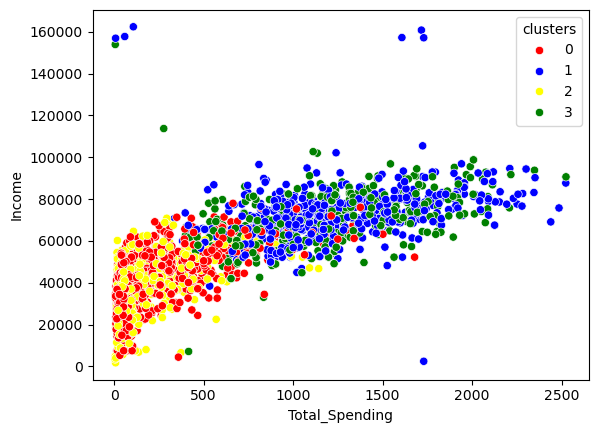

In [98]:
# Income and spending trend
sns.scatterplot(x = X["Total_Spending"], y =X["Income"], hue= X["clusters"], palette =pal)

# Analysis of above scatter plot of Income vs Total_Spending

In [99]:


    # Cluster 0 (red) :
        # low/ moderate income 
        # low/ moderate total_spending

    # Cluster 1 (blue) :
        # high income
        # high spend

    # Cluster 2 (yellow) :
        # low income 
        # low total_spending

    # Cluster 3 (green) :
        # moderate income
        # high spend

In [102]:
# Cluster summary
cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39690.143646  48.914917           2.594475         3.153591   
1         72814.928839  49.202247           1.958801         5.687266   
2         36973.788288  48.319820           2.594595         2.713964   
3         70730.036827  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  customer_tenure_days  Total_Spending  \
clu

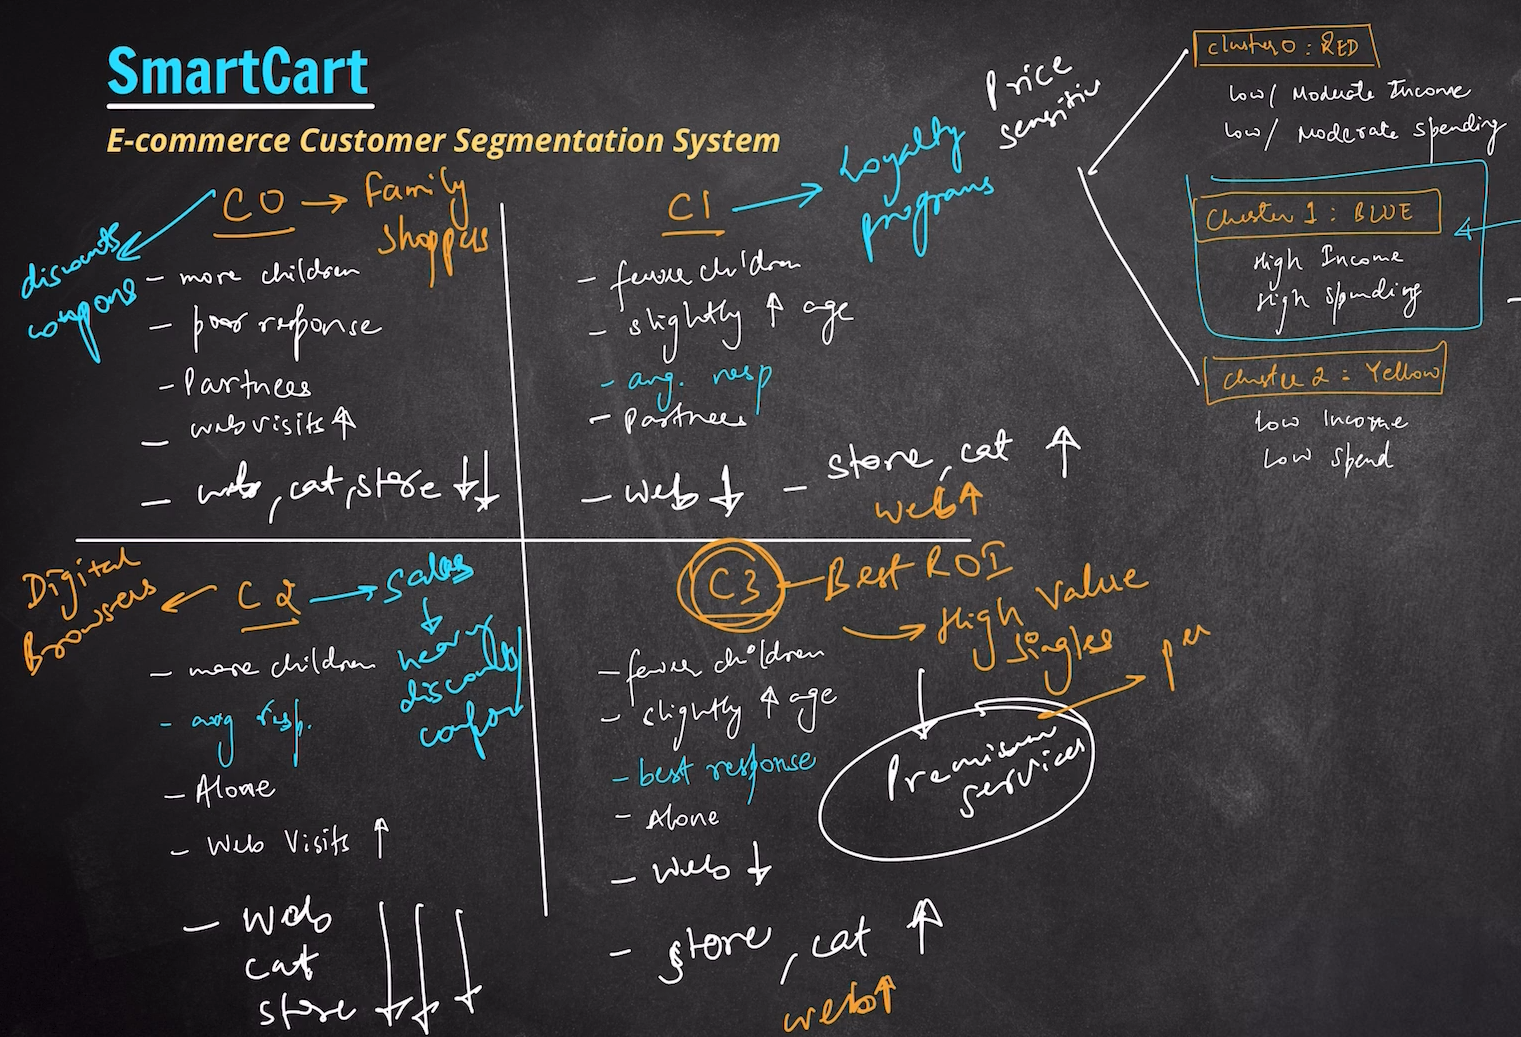